# Root Simulate Learning While Walking

This is the main program that simulates learning while walking, converted from the MATLAB version.
Run the cells in order from top to bottom.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Parameters

In [2]:
# Import functions for loading parameters
from parameter_loading.load_biped_model_parameters import load_biped_model_parameters
from parameter_loading.load_sensory_noise_parameters import load_sensory_noise_parameters
from parameter_loading.load_controller_gain_parameters import load_controller_gain_parameters
from parameter_loading.load_learner_parameters import load_learner_parameters
from parameter_loading.load_protocol_parameters import load_protocol_parameters
from parameter_loading.load_stored_memory_parameters_control_vs_speed import load_stored_memory_parameters_control_vs_speed

In [3]:
# Initialize parameters
param_fixed = {}
np.random.seed() 

# Load parameters 
param_fixed = load_biped_model_parameters(param_fixed)
param_fixed = load_sensory_noise_parameters(param_fixed)
param_controller_gains = load_controller_gain_parameters(param_fixed)
param_fixed = load_learner_parameters(param_fixed)
param_fixed = load_protocol_parameters(param_fixed)
param_fixed = load_stored_memory_parameters_control_vs_speed(param_fixed)

print("Parameters loaded successfully!")
print(f"Default number of learning iterations: {param_fixed.get('num_iterations', 'Unknown')}")

Parameters loaded successfully!
Default number of learning iterations: 3200


## 3. Initialize Body Parameters and Context

In [4]:
from initializing.load_learnable_parameters_initial import load_learnable_parameters_initial
from initializing.load_initial_body_state import load_initial_body_state
from initializing.get_treadmill_speed import get_treadmill_speed

In [5]:
# Load initial learnable parameters and body state
p_input_controller_asymmetric_nominal = load_learnable_parameters_initial(param_fixed)
state_var0_model = load_initial_body_state(p_input_controller_asymmetric_nominal)
t_start = 0

# Store initial state for later use in post-processing
state_var0_model_before_learning = state_var0_model.copy()

print("Initial controller parameters:", p_input_controller_asymmetric_nominal)
print("Initial body state:", state_var0_model)

Initial controller parameters: [ 3.28221263e-01  3.10751797e-01  1.53556844e-01  0.00000000e+00
  0.00000000e+00  3.28221491e-01  3.10751695e-01  1.53557221e-01
 -3.89537350e-08 -3.89537350e-08]
Initial body state: [0.        0.3107518 0.        0.        0.35     ]


In [6]:
# Get context for the gait (treadmill speeds)
vA, vB = get_treadmill_speed(0, param_fixed['imposedFootSpeeds'])
context_now = np.array([vA, vB])
context_length = len(context_now)

print("Treadmill speeds (context):", context_now)

Treadmill speeds (context): [-0.3276 -0.3276]


## 4. Learning Simulation

In [7]:
from learning.simulate_learning_step_by_step import simulate_learning_step_by_step

In [8]:
# IMPORTANT: Set number of iterations for simulation
# For testing: use a small number (e.g., 10)
# For full simulation: use the original value (3200)
param_fixed['num_iterations'] = 100  # Change this to 3200 for full simulation

print(f"Running learning simulation with {param_fixed['num_iterations']} iterations...")

# Run the learning simulation
pInputControllerStore_OnesTried = simulate_learning_step_by_step(
    param_fixed,
    p_input_controller_asymmetric_nominal, 
    state_var0_model,
    context_now,
    param_controller_gains
)

print(f"Learning simulation completed! Result shape: {pInputControllerStore_OnesTried.shape}")

Running learning simulation with 3200 iterations...
Simulating Learning While Walking ... (3200 strides)
iStride = 50
iStride = 100
iStride = 150
iStride = 200
iStride = 250
iStride = 300
iStride = 350
iStride = 400
iStride = 450
iStride = 500
iStride = 550
iStride = 600
iStride = 650
iStride = 700
iStride = 750
iStride = 800
iStride = 850
iStride = 900
iStride = 950
iStride = 1000
iStride = 1050
iStride = 1100
iStride = 1150
iStride = 1200
iStride = 1250
iStride = 1300
iStride = 1350
iStride = 1400
iStride = 1450
iStride = 1500
iStride = 1550
iStride = 1600
iStride = 1650
iStride = 1700
iStride = 1750
iStride = 1800
iStride = 1850
iStride = 1900
iStride = 1950
iStride = 2000
iStride = 2050
iStride = 2100
iStride = 2150
iStride = 2200
iStride = 2250
iStride = 2300
iStride = 2350
iStride = 2400
iStride = 2450
iStride = 2500
iStride = 2550
iStride = 2600
iStride = 2650
iStride = 2700
iStride = 2750
iStride = 2800
iStride = 2850
iStride = 2900
iStride = 2950
iStride = 3000
iStride = 3050


## 5. Convert 8D to 10D Format

In [9]:
# Convert the 8D back up to 10D to use the old functions (following MATLAB code)
pInputControllerStore_8D = pInputControllerStore_OnesTried
pInputControllerStore_10D = np.vstack([
    pInputControllerStore_8D[:3, :],   # First 3 rows
    np.zeros((2, pInputControllerStore_8D.shape[1])),  # Add 2 rows of zeros  
    pInputControllerStore_8D[3:8, :]   # Rows 4-8 from original
])

print(f"Converted from 8D shape {pInputControllerStore_8D.shape} to 10D shape {pInputControllerStore_10D.shape}")
print("First few columns of 10D result:")
print(pInputControllerStore_10D[:, :min(3, pInputControllerStore_10D.shape[1])])

Converted from 8D shape (8, 25383) to 10D shape (10, 25383)
First few columns of 10D result:
[[ 0.33450251  0.32959134  0.32643813]
 [ 0.31283606  0.31287834  0.30844381]
 [ 0.15335819  0.15239719  0.15524567]
 [ 0.          0.          0.        ]
 [ 0.          0.          0.        ]
 [ 0.32720566  0.32947528  0.32747653]
 [ 0.30979454  0.31282692  0.30921003]
 [ 0.15327779  0.15063971  0.15476408]
 [-0.00164716  0.00197246  0.00136754]
 [-0.00383433  0.00058082  0.00156877]]


## 6. Post-Processing and Visualization

In [10]:
# Import post-processing functions
from post_processing.post_process_after_learning import post_process_after_learning
from post_processing.post_process_helper_plots import post_process_helper_plots

In [11]:
# Post-process outputs and make plots
do_animate = False  # Set to True if you want animations (not fully implemented yet)

print("Starting post-processing...")

(
    final_state,
    t_store_full,
    state_store_full,
    emet_total_store_full,
    emet_per_time_store_full,
    t_step_store_full,
    ework_pushoff_store_full,
    ework_heelstrike_store_full,
    edot_store_iteration_average,
    t_total_iteration_store,
) = post_process_after_learning(
    pInputControllerStore_10D,
    state_var0_model_before_learning,
    param_controller_gains,
    param_fixed,
    do_animate
)

print("Post-processing completed!")

Starting post-processing...
Post-processing all the walking data ... (25383 iterations)
  iStride = 50
  iStride = 100
  iStride = 150
  iStride = 200
  iStride = 250
  iStride = 300
  iStride = 350
  iStride = 400
  iStride = 450
  iStride = 500
  iStride = 550
  iStride = 600
  iStride = 650
  iStride = 700
  iStride = 750
  iStride = 800
  iStride = 850
  iStride = 900
  iStride = 950
  iStride = 1000
  iStride = 1050
  iStride = 1100
  iStride = 1150
  iStride = 1200
  iStride = 1250
  iStride = 1300
  iStride = 1350
  iStride = 1400
  iStride = 1450
  iStride = 1500
  iStride = 1550
  iStride = 1600
  iStride = 1650
  iStride = 1700
  iStride = 1750
  iStride = 1800
  iStride = 1850
  iStride = 1900
  iStride = 1950
  iStride = 2000
  iStride = 2050
  iStride = 2100
  iStride = 2150
  iStride = 2200
  iStride = 2250
  iStride = 2300
  iStride = 2350
  iStride = 2400
  iStride = 2450
  iStride = 2500
  iStride = 2550
  iStride = 2600
  iStride = 2650
  iStride = 2700
  iStride = 27

Creating plots...
\n=== Simulation Summary ===
Total steps: 50766
Total simulation time: 95354.972
Average step duration: 1.8783
Average energy per step: 107363.838765
Average energy rate: 4736984484.481389
Initial average energy: 0.046145
Final average energy: 32.950876
Energy improvement: -71307.49%


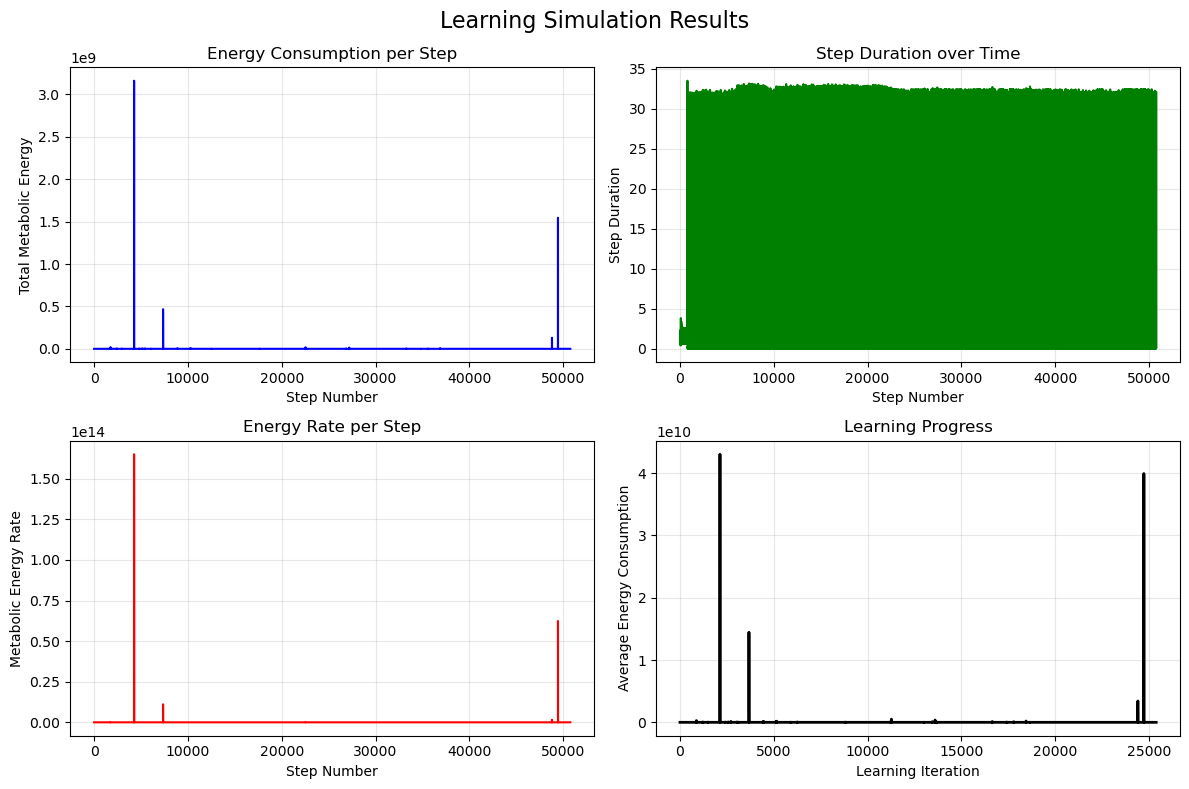

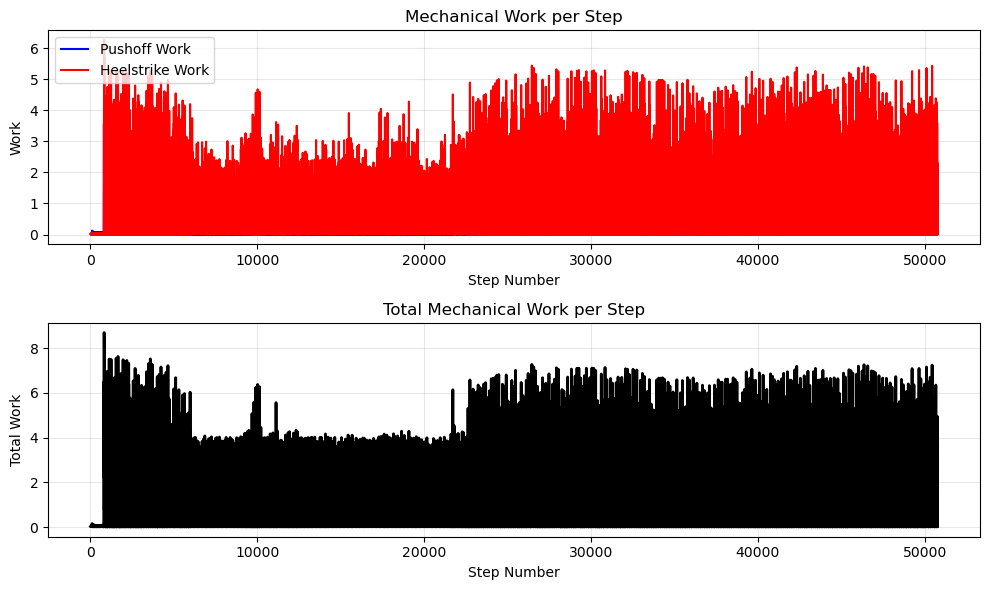


Simulation and analysis complete!


In [13]:
# Create plots and summary statistics
print("Creating plots...")

post_process_helper_plots(
    final_state,
    t_store_full,
    state_store_full,
    emet_total_store_full,
    emet_per_time_store_full,
    t_step_store_full,
    param_controller_gains,
    param_fixed,
    do_animate,
    ework_pushoff_store_full,
    ework_heelstrike_store_full,
    edot_store_iteration_average,
    t_total_iteration_store,
)

print("\nSimulation and analysis complete!")

## Summary

This notebook has successfully converted and run the MATLAB learning simulation in Python. The simulation includes:

1. **Parameter Loading**: All model, controller, learner, and protocol parameters
2. **Initialization**: Initial body state and controller parameters
3. **Learning Simulation**: Step-by-step reinforcement learning
4. **Post-Processing**: Detailed trajectory analysis and energy consumption
5. **Visualization**: Plots showing learning progress and simulation results
